# AMSS-NCKU-Python 运行流程

这是一个用 jupyter notebook 运行 AMSS-NCKU-Python 的工作流程
其代码与 AMSS_NCKU_Program.py 基本一致
（如果遇到 bug，可以返回 python 脚本运行 python3 AMSS_NCKU_Program.py）

## 1 预备操作 

### 设定 AMSS-NCKU-Python 输出界面的语言

In [1]:

##################################################################
## 程序即将开始，选择屏幕终端的输出语言
##################################################################

import logo
import main_program_function

## 输出本程序的 logo
logo.print_logo()

## 让用户选择一语言    
input_language = main_program_function.setting_language() 



 W     W     W  E E E E   L           C C C      O O O       M     M      E E E E          T T T T T    O O O   
  W   W W   W   E         L         C          O       O    M M   M M     E                    T      O       O 
  W   W W   W   E E E E   L         C          O       O   M   M M   M    E E E E              T      O       O 
   W W   W W    E         L         C          O       O   M   M M   M    E                    T      O       O 
    W     W     E E E E   L L L L     C C C      O O O    M     M     M   E E E E              T        O O O   


     A        M     M     S S S S   S S S S      N     N     C C C   K     K   U     U      P P P     Y      Y  
    A A      M M   M M    S         S            N N   N   C         K   K     U     U      P     P     Y   Y   
   A   A    M   M M   M   S S S S   S S S S  --  N  N  N   C         K K       U     U      P     P       Y     
  A A A A   M   M M   M         S         S      N   N N   C         K   K     U     U      P

### 输出 AMSS-NCKU-Python 的说明

In [2]:

##################################################################
## 输出本程序的说明
##################################################################

import print_information

if ( input_language == "Chinese" ):
    print_information.print_program_introduction_Chinese()
elif ( input_language == "English" ):
    print_information.print_program_introduction_English()




------------------------------------------------------------------------------------------

     Numerical Relativity AMSS-NCKU  

     Author of AMSS-NCKU Code: Zhou-Jian Cao et al. 
     Author of AMSS-NCKU Python Interface: Xiao Qu 

     AMSS-NCKU is an open source numerical relativity code 
     It can be used to simulate the dynamical evolution on mergering process of black hole systems, 
 calculating the variation of gravitational field, black holes' trajectories, and gravitational wave 
 emissions through directly solving the Einstein field equations  

     This AMSS-NCKU code uses the finite-difference method to evaluate the numerical simulation. The 
 finite-difference schemes can be chosen as: 2nd order, 4th order, 6th order, 8th order. 
     The computation equation form in AMSS-NCKU code can be chosen as: BSSN equations, Z4C equations, 
 BSSN equations coupled with scalars (in f(R) theory), BSSN equations coupled with electromagnetic 
 fields. 
     The numerical grid sy

## 2 设定 AMSS-NCKU 相关的参数 

### 设定相关的参数 

利用下面的魔术命令生成对应的 AMSS_NCKU_Input.py 

%%writefile AMSS_NCKU_Input.py

In [3]:
%%writefile AMSS_NCKU_Input.py

#################################################
## 这里包含了数值相对论所需要的输入
#################################################

import numpy  

#################################################
## 设置程序运行目录和计算资源
## Setting MPI processes and the output file directory
#################################################

File_directory   = "BBH_jupyter_test"            ## 程序运行目录             output file directory
Output_directory = "binary_output"               ## 存放二进制数据的子目录     binary data file directory
                                                 ## The file directory name should not be too long
MPI_processes    = 4                             ## 想要调用的进程数目        number of mpi processes used in the simulation
OMP_processes    = 4                             ## 想要调用的线程数目        number of OpenMP threads per MPI process
cores_per_numa   = OMP_processes                 ## number of CPU cores per NUMA node (for processor binding)

GPU_Calculation  = "no"                          ## 是否开启 GPU 计算，可选 yes 或 no   Use GPU or not 
                                                 ## (prefer "no" in the current version, because the GPU part may have bugs when integrated in this Python interface)
CPU_Part         = 1.0
GPU_Part         = 0.0


#################################################
## 设置物理系统和程序计算方法
## Setting the physical system and numerical method
#################################################

Symmetry                 = "equatorial-symmetry"   ## Symmetry of System: choose equatorial-symmetry, no-symmetry, octant-symmetry
                                                   ## 注意：如果选择 octant-symmetry 最好使用固定网格计算，octant-symmetry 对移动网格有些 bug 
Equation_Class           = "BSSN"                  ## Evolution Equation: choose "BSSN", "BSSN-EScalar", "BSSN-EM", "Z4C" 
                                                   ##       BSSN 和 Z4C   适合于 GR 旋转黑洞的真空计算
                                                   ##       BSSN-EM      涉及 GR 带电黑洞的真空计算
                                                   ##       BSSN-EScalar 涉及到标量张量-F(R) 理论的计算，需要在后面设定额外参数
                                                   ## 注意：GPU 计算仅支持 BSSN      GPU calculation only supports "BSSN"
                                                   ## 这里选择 BSSN-EScalar，需要在后面设定 F(R) 理论的参数
                                                   ## If "BSSN-EScalar" is chosen, it is necessary to set other parameters below
Initial_Data_Method      = "Ansorg-TwoPuncture"    ## 设置求解数值相对论初值的方法
                                                   ## initial data method: choose "Ansorg-TwoPuncture", "Lousto-Analytical", "Cao-Analytical", "KerrSchild-Analytical"
                                                   ## 注意：当前 BSSN-EM 的计算不支持用解析公式 Lousto-Analytical、Cao-Analytical、KerrSchild-Analytical
                                                   ##       当前 BSSN-EScalar 的计算不支持用解析公式 Lousto-Analytical、Cao-Analytical、KerrSchild-Analytical
Time_Evolution_Method    = "runge-kutta-45"        ## 时间演化方法     time evolution method: choose "runge-kutta-45"
Finite_Diffenence_Method = "6th-order"             ## 有限差分方法     finite-difference method: choose "2nd-order", "4th-order", "6th-order", "8th-order"


#################################################
## 设置时间演化信息
## Setting the time evolutionary information
#################################################

Start_Evolution_Time     = 0.0                    ## 起始演化时间   start evolution time t0
Final_Evolution_Time     = 800.0                   ## 最终演化时间   final evolution time t1
Check_Time               = 100.0
Dump_Time                = 100.0                  ## 每隔一定时间间隔储存数据   time inteval dT for dumping binary data
D2_Dump_Time             = 100.0                  ## dump the ascii data for 2d surface after dT'
Analysis_Time            = 0.1                    ## dump the puncture position and GW psi4 after dT"
Evolution_Step_Number    = 10000000               ## 最大迭代次数       stop the calculation after the maximal step number
Courant_Factor           = 0.5                    ## Courant 因子（决定每一步时间演化的时间间隔）    Courant Factor
Dissipation              = 0.15                   ## 耗散因子                                                                                    Kreiss-Oliger Dissipation Strength


#################################################
## 设置AMR网格信息
## Setting the AME grid structure
#################################################

basic_grid_set    = "Patch"                          ## 设定网格类型，可选 Patch 和 Shell-Patch     grid structure: choose "Patch" or "Shell-Patch"
grid_center_set   = "Cell"                           ## 网格中心设置，可选 Cell 和 Vertex           grid center: chose "Cell" or "Vertex"

grid_level        = 10                               ## 设置格点的总层数              total number of AMR grid levels
static_grid_level = 6                                ## 设置静态格点的层数            number of AMR static grid levels
moving_grid_level = grid_level - static_grid_level   ## 可移动格点的层数             number of AMR moving grid levels

analysis_level    = 0
refinement_level  = 4                                ## 从该层开始进行时间细化        time refinement start from this grid level

largest_box_xyz_max = [600.0, 600.0, 600.0]          ## 设置最外层格点的坐标最大值     scale of the largest box
                                                     ## not ne cess ary to be cubic for "Patch" grid s tructure
                                                     ## need to be a cubic box for "Shell-Patch" grid structure
## largest_box_xyz_min = - numpy.array(largest_box_xyz_max)  ## 设置最外层格点的坐标最小值
largest_box_xyz_min = [-600.0, -600.0, -600.0]

static_grid_number = 96                              ## 设置固定格点每一层每一维数的格点数目（这里对应的 x 轴格点数目，yz 轴格点自动调整）
                                                     ## grid points of each static AMR grid (in x direction)
                                                     ## (grid points in y and z directions are automatically adjusted)
moving_grid_number = 48                              ## 设置可移动格点每一层每一维数的格点数目               grid points of each moving AMR grid
shell_grid_number  = [32, 32, 100]                   ## 设置最外层球状网格（shell patch）的格点数目     grid points of Shell-Patch grid
                                                     ## 以 phi、theta、r 的顺序给定                                        in (phi, theta, r) direction
devide_factor      = 2.0                             ## 设置相邻两层网格分辨率的比例（不要轻易改变）
                                                     ## resolution between different grid levels dh0/dh1, only support 2.0 now

static_grid_type   = 'Linear'                        ## 设置固定格点的类型，可选 'Linear'      AMR static grid structure , only supports "Linear"
moving_grid_type   = 'Linear'                        ## 设置可移动格点的类型，可选 'Linear'    AMR moving grid structure , only supports "Linear"

quarter_sphere_number = 96                           ## 1/4 球面积分的格点数目
                                                     ## grid number of 1/4 s pher ical surface
                                                     ## (which is needed for evaluating the spherical surface integral)

#################################################

## 设置黑洞 puncture（穿刺法）的信息
## Setting the puncture information
#################################################

puncture_number       = 2                                     

position_BH           = numpy.zeros( (puncture_number, 3) )   
parameter_BH          = numpy.zeros( (puncture_number, 3) )   
dimensionless_spin_BH = numpy.zeros( (puncture_number, 3) )   
momentum_BH           = numpy.zeros( (puncture_number, 3) )   

puncture_data_set     = "Automatically-BBH"              ## 设置双星轨道坐标的方式，可选 Manually 和 Automatically-BBH
                                                         ## Method to give Puncture’s positions and momentum
                                                         ## choose "Manually" or "Automatically-BBH"
                                                         ## Prefer to choose "Manually", because "Automatically-BBH" is developing now

##---------------------------------------------

## 设置每个黑洞的参数 (M Q* a*)  
## black hole parameter (M Q* a*)
## 质量  无量纲电荷  无量纲自旋
parameter_BH[0] = [ 0.5,  0.0,  0.0 ]   
parameter_BH[1] = [ 0.5,  0.0,  0.0 ] 
## parameter_BH[2] = [ 0.5,  0.0,  0.0 ]   ## 多黑动手动添加
## 注意，如果求解数值相对论初值的方法选为 Ansorg-TwoPuncture ，第一个黑洞必须为质量较大的那个，且黑洞总质量会自动 rescale 为 M=1 （其它情况下必须手动 rescale）

## 设置每个黑洞的无量纲自旋
## dimensionless spin in each direction
## 无对称性时 ，需要手动给 3 个方向的自旋角动量
dimensionless_spin_BH[0] = [ 0.0,  0.0,  0.0 ]   
dimensionless_spin_BH[1] = [ 0.0,  0.0,  0.0 ]  
## dimensionless_spin_BH[2] = [ 0.0,  0.0,   0.0  ]  ## 多黑动手动添加

##---------------------------------------------
## 如果设置双星初始轨道坐标的方式选为 Automatically-BBH，只需要给定黑洞参数，偏心率，距离即可
##---------------------------------------------

## 这一步与初值求解中的 Ansorg-TwoPuncture 配合使用中需要注意的问题
## 用 Ansorg-TwoPuncture 求解初值，轨道坐标设置可以设置 Manually 和 Automatically-BBH 设置双星轨道坐标
## 但双星轨道坐标如果设置为 Manually 而不是 Automatically-BBH，则要细致设置 Puncture 的位置和动量取值，否则可能会使 TwoPuncture 程序无法正确读入输入而报错）

## 双黑洞系统的初始间距
## initial orbital distance and ellipticity for BBHs system
## ( needed for "Automatically-BBH" case , not affect the "Manually" case )
Allow_PN_Evaluation = "yes"  ## 是否允许从更远的位置进行后牛顿演化，以提高计算精度
Distance_initial = 60.0
e0               = 0.0
Distance_final   = 9.0

## 注意，如果设置双星初始轨道坐标的方式选为 Automatically-BBH，则程序自动调整将较大质量黑洞放在 y 轴正向，将较小质量黑洞放在 y 轴负向
##       如果设置双星初始轨道坐标的方式选为 Manually，且则需要手动调整到 y 轴方向 
## use Brugmann's convention
##  -----0-----> y
##   -      +     

##---------------------------------------------
## 如果设置 puncture 初始轨道坐标的方式选为 Manually，还需要手动给定所有黑洞参数
## If puncture_data_set is chosen to be "Manually", it is necessary to set the position and momentum of each puncture manually
##---------------------------------------------

## 设置每个黑洞的初始位置     initial position for each puncture
position_BH[0]  = [  0.0, +4.5, 0.0 ]  
position_BH[1]  = [  0.0, -4.5, 0.0 ] 
## position_BH[2]  = [  0.0, 0.0, 0.0 ]  ## 多黑洞手动添加

## 设置每个黑洞的动量信息    initial mumentum for each puncture
## (needed for "Manually" case, does not affect the "Automatically-BBH" case)
momentum_BH[0]  = [ 0.0,  0.0,   0.0 ]
momentum_BH[1]  = [ 0.0,  0.0,   0.0 ]
## momentum_BH[2]  = [ 0.0,  0.0,  0.0 ]  ## 多黑洞手动添加

##---------------------------------------------


#################################################
## 设置引力波和探测器的相关信息
## Setting the gravitational wave information
#################################################

GW_L_max        = 4                      ## 引力波最大的 L    maximal L number in gravitational wave
GW_M_max        = 4                      ## 引力波最大的 M    maximal M number in gravitational wave
Detector_Number = 11                     ## 探测器的数目            number of dector
Detector_Rmin   = 50.0                   ## 最近探测器的距离   nearest dector distance
Detector_Rmax   = 150.0                  ## 最远探测器的距离   farest dector distance

#################################################


#################################################

## 设置表观视界的参数
## Setting the apprent horizon

AHF_Find       = "no"                    ## 是否开启表观视界计算，可选 yes 或 no

AHF_Find_Every = 24
AHF_Dump_Time  = 20.0

#################################################



#################################################

## 设置二进制画图相关信息

plot_binary_data_set         = "xy-xz-yz-plot"             ## 选择 "xy-plot", "xz-plot", "yz-plot", "xy-xz-yz-plot"
## plot_binary_data_type        = "Linear"                 ## 对哈密顿约束，TrK这些数据画图选择
                                                           ## 选择 "Linear", "Logarithmic"
                                                           ## 后续开发
plot_binary_data_level       = "All-Level"                 ## 选择 "All-level", "Single-level"
plot_binary_data_levelnumber = static_grid_level - 1       ## 选择对哪个层来进行画图
plot_binary_data_processes   = OMP_processes               ## 二进制数据并行画图使用的进程数目       number of processes used in parallel binary data plotting
                                                           ## 如果设为 0，则自动使用所有 CPU 核数   if set to 0, all CPU cores are used automatically

#################################################


#################################################

## 标量-张量-f(R) 理论的一些参数
## 仅对 BSSN-EScalar 的计算有影响
## Other parameters (testing)
## Only influence the Equation_Class = "BSSN-EScalar" case

FR_a2     = 3.0        ## f(R) = R + a2 * R^2    
FR_l2     = 10000.0
FR_phi0   = 0.00005
FR_r0     = 120.0
FR_sigma0 = 8.0
FR_Choice = 2          ## Choice 1 2 3 4 5
                       ## 可选为 1 2 3 4 5
                       ## 1: phi(r) = phi0 * Exp(-(r-r0)**2/sigma0)  
                       ##    V(r)   = 0
                       ## 2: phi(r) =  phi0 * a2^2/(1+a2^2)  
                       ##    V(r)   = Exp(-8*Sqrt(PI/3)*phi(r)) * (1-Exp(4*Sqrt(PI/3)*phi(r)))**2 / (32*PI*a2)
                       ## 3: Schrodinger-Newton 系统给定的 phi(r) 
                       ##    V(r)   = Exp(-8*Sqrt(PI/3)*phi(r)) * (1-Exp(4*Sqrt(PI/3)*phi(r)))**2 / (32*PI*a2)
                       ## 4: phi(r) = phi0 * 0.5 * ( tanh((r+r0)/sigma0) - tanh((r-r0)/sigma0) )  
                       ##    V(r)   = 0
                       ## 5: phi(r) = phi0 * Exp(-(r-r0)**2/sigma)   
                       ##    V(r)   = 0


#################################################
## 其它选项，还在测试中
## 但不建议用户轻易改动这些选项
## Other parameters (testing)
## (please do not change if not necessary)
#################################################

boundary_choice = "BAM-choice"     ## 索莫菲边界条件设定，可选 "BAM-choice" 和 "Shibata-choice"
                                   ## Sommerfeld boundary condition : choose "BAM-choice" or "Shibata-choice" 
                                   ## 目前的版本定建议选为 "BAM-choice"          
                                   ## prefer "BAM-choice"

gauge_choice  = 0                  ## 规范条件选取
                                   ## 0: B^i gauge
                                   ## 1: David's puncture gauge
                                   ## 2: MB B^i gauge               ## 对Z4C和GPU计算好像有bug
                                   ## 3: RIT B^i gauge
                                   ## 4: MB beta gauge 
                                   ## 5: RIT beta gauge 
                                   ## 6: MGB1 B^i gauge
                                   ## 7: MGB2 B^i gauge
                                   ## 目前的版本建议选为 0 或 1
                                   ## prefer 0 or 1
                                   
tetrad_type  = 2                   ## tetradtype 
                                   ## 选取 0 1 2
                                   ## choose 0 1 2
                                   ## 目前的版本建议选为 2
                                   ## prefer 2
                
                                   ## 以下   v:r; u: phi; w: theta
                                   ##       v^a = (x,y,z)
                                   ## 0: orthonormal order: v,u,w
                                   ##    v^a = (x,y,z)   
                                   ##    m = (phi - i theta)/sqrt(2) 
                                   ##    following Frans, Eq.(8) of  PRD 75, 124018(2007)
                                   ## 1: orthonormal order: w,u,v
                                   ##    m = (theta + i phi)/sqrt(2) 
                                   ##    following Sperhake, Eq.(3.2) of  PRD 85, 124062(2012)    
                                   ## 2: orthonormal order: v,u,w
                                   ##    v_a = (x,y,z)
                                   ##    m = (phi - i theta)/sqrt(2) 
                                   ##    following Frans, Eq.(8) of  PRD 75, 124018(2007)
                                    
################################################# 


Overwriting AMSS_NCKU_Input.py


### 确认参数正确并导入参数文件 

In [4]:

##################################################################
## 确认参数并导入参数
##################################################################

## 屏幕输出程序开始运行前的提示
print_information.print_begin_program( input_language )


###############################
## 如果同意继续运算，则输入回车
###############################
## inputvalue = input()   ## 设定一个输入（回车），以便程序下一步运行         
## print()

###############################
## 上述操作针对用命令行运行 python
## Jupyter Notebook中不再需要上述暂停
###############################


## 导入参数文件

## 这样似乎不能导入最新的值
## import AMSS_NCKU_Input as input_data  ## 导入参数文件

## 要使用如下方式导入才行

import AMSS_NCKU_Input as input_data
import importlib

importlib.reload(input_data)



 Simulation will be started, please confirm you have set the correct parameters in the script file 
 AMSS_NCKU_Input.py 

 If parameters have been set correctly, press Enter to continue !!!  

 If you have not set parameters, press Ctrl+C to abort the simulation and adjust the parameters 
 in script file AMSS_NCKU_Input.py !!! 



<module 'AMSS_NCKU_Input' from '/home/zrway/AMSS-NCKU-Python-Data/version 12d/AMSS_NCKU_Input.py'>

## 3 根据设定的参数，生成 AMSS-NCKU 所需要的输入文件和文件目录

### 生成 AMSS-NCKU 程序运行目录，用于存储数据文件

In [5]:

##################################################################
## 生成文件目录，用来储存程序运行的数据
##################################################################

import os
import shutil


## 根据输入文件来设置文件目录
File_directory = os.path.join(input_data.File_directory)   

## 检查设定的输出目录是否存在，并根据用户的输入决定继续计算还是终止计算
main_program_function.continue_or_stop( File_directory, input_language )
        
## 如果文件目录已经存在，则去除它
shutil.rmtree(File_directory, ignore_errors=True)

## 创建文件夹
os.mkdir(File_directory)

## 复制 python 输入文件到程序运行目录
shutil.copy("AMSS_NCKU_Input.py", File_directory)

## 生成文件目录，用来存放各类输出文件

output_directory = os.path.join(File_directory, "AMSS_NCKU_output")
os.mkdir(output_directory)

binary_results_directory = os.path.join(output_directory, input_data.Output_directory)
os.mkdir(binary_results_directory)

figure_directory = os.path.join(File_directory, "figure")
os.mkdir(figure_directory)

video_directory = os.path.join(File_directory, "video")
os.mkdir(video_directory)

## 屏幕输出文件目录已生成
print_information.print_make_directory( input_language )



 Output directory has been generated 



### 输出对应的 AMR 网格信息，检查网格是否符合要求

In [6]:

##################################################################
## 输出相关的参数信息
##################################################################

import setup

setup_data = setup.setup( input_language ) 

## 输出相关的参数信息
if ( input_language == "Chinese" ):
    setup.print_input_data_Chinese( setup_data, File_directory )
elif ( input_language == "English" ):
    setup.print_input_data_English( setup_data, File_directory )


###############################
## 如果分辨率满足要求，则进行下一步计算
###############################

print_information.print_whether_grid_is_satisfied( input_language )

## inputvalue = input()  ## 设定一个输入（回车），以便程序下一步运行
## print()

###############################
## 上述输入回车的操作是针对用命令行运行 python
## Jupyter Notebook中不再需要上述暂停
###############################


------------------------------------------------------------------------------------------


 Printing the basic parameter and setting in the AMSS-NCKU simulation 

 The number of MPI processes in the AMSS-NCKU simulation =  4

 The form of computational equation  =  BSSN
 The initial data in this simulation =  Ansorg-TwoPuncture

 Starting evolution time   =  0.0
 Final evolution time      =  800.0
 Maximal iteration number  =  10000000
 Courant factor            =  0.5
 Strength of dissipation   =  0.15
 Symmetry of system        =  equatorial-symmetry
 The Runge-Kutta scheme in the time evolution   =  runge-kutta-45
 The finite-difference scheme in the simulation =  6th-order

 The static AMR grid type =  Linear
 The moving AMR grid type =  Linear

 The number of static AMR grid levels =  6
 The number of moving AMR grid levels =  4
 The number of total  AMR grid levels =  10

 The grid number of each static AMR grid level =  96
 The grid number of each moving AMR grid level =  48



### 检查导入的 puncture 信息，检查 puncture 信息是否符合要求

In [7]:

##################################################################
## 初始化并输出 puncture 相关的信息
##################################################################


import puncture_initialize

## 初始化 puncture 数据
puncture_data = puncture_initialize.generate_puncture_input_data( input_language )

## 屏幕输出 puncture 的信息
puncture_initialize.print_puncture_information( input_language, puncture_data )

## inputvalue = input()  ## 设定一个输入（回车），以便程序下一步运行
## print() 

###############################
## 上述输入回车的操作是针对用命令行运行 python
## Jupyter Notebook中不再需要上述暂停
###############################



 Setting Puncture's position, momentum and angular momentum 


 Calculating the physical quantities of binary star orbits 

 The mass of the binary stars are:               M1 = 0.5  M2 = 0.5 
 The dimensionless spin of the binary stars are: S1 = [0. 0. 0.]  S2 = [0. 0. 0.] 
 The semi major axis and eccentricity of the binary orbit are: a0 = D0/2 = 4.5  e0 = 0.0 

 begin the calculation 

 individual mass of binary system: M1 = 0.5  M2 = 0.5  total mass: M_total = 1.0 
 reduced mass: M_mu =  0.25
 dimensionless mass ratio: Q = M1 / M2 =  1.0
 individual mass (dimensionless) : m1 = M1/M_total = 0.5  m2 = M1/M_total = 0.5 
 reduced    mass (dimensionless) : m_mu = M_mu/M_total = 0.25 m_eta = Q / (1+Q)^2 = 0.25 

 Calculate the orbital coordinates of binary stars  

 The coordinates of the binary star at t=0: Y1 = [0.0, 4.5, 0.0]  Y2 = [0.0, -4.5, 0.0]

 Post-Newton expansion parameter epsilon = M/r =  0.1111111111111111


 angular velocity of binary stars system at 0   PN =  0.037037037

### 设定初始时刻的 AMR 网格，并利用这些信息生成 AMSS-NCKU 所需的参数文件¶


 Wirte Down The Grid Information 

 Number of Total Grid Level =  10
 Number of Static Grid Level =  6
 Number of Moving Grid Level =  4


 Setting the demanded numerical grid 


 adjusting the static gird points, making the original point (0,0,0) to the static gird points 


 adjusting the moving gird points, ensuring the alliance of moving grids points and static grids points 

 adjust_puncture[6,0,0] = 0.0 
 adjust_puncture[6,0,1] = 4.4921875 
 adjust_puncture[6,0,2] = 0.0 
 adjust_puncture[6,1,0] = 0.0 
 adjust_puncture[6,1,1] = -4.4921875 
 adjust_puncture[6,1,2] = 0.0 
 adjust_puncture[7,0,0] = 0.0 
 adjust_puncture[7,0,1] = 4.4921875 
 adjust_puncture[7,0,2] = 0.0 
 adjust_puncture[7,1,0] = 0.0 
 adjust_puncture[7,1,1] = -4.4921875 
 adjust_puncture[7,1,2] = 0.0 
 adjust_puncture[8,0,0] = 0.0 
 adjust_puncture[8,0,1] = 4.4921875 
 adjust_puncture[8,0,2] = 0.0 
 adjust_puncture[8,1,0] = 0.0 
 adjust_puncture[8,1,1] = -4.4921875 
 adjust_puncture[8,1,2] = 0.0 
 adjust_puncture[9,

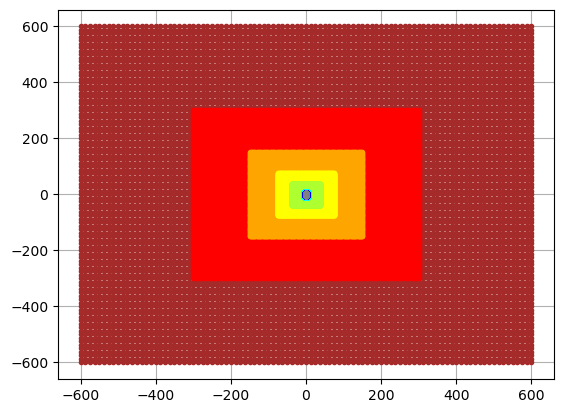

In [8]:

##################################################################
## 设定初始时刻的 AMR 网格
##################################################################

import numerical_grid        

## 生成一个初始时刻的AMR网格
initial_AMR_grid_data = numerical_grid.generate_initial_AMR_grid( input_language, puncture_data )

## 画出初始的格点设置
numerical_grid.plot_initial_grid( input_language, initial_AMR_grid_data )


In [9]:

##################################################################
## 根据网格信息自动生成 AMSS-NCKU C++ 程序的输入文件
##################################################################


## 根据设定的参数生成 AMSS-NCKU 程序的输入文件   
setup.generate_AMSSNCKU_input( input_language )

## 根据格点信息生成 cgh 的相关输入
numerical_grid.append_AMSSNCKU_cgh_input( input_language, initial_AMR_grid_data )  


##  根据算法和参数生成 AMSS-NCKU 的宏文件
main_program_function.generate_macrodef_file( input_language )



 Automatically generating the input parfile for AMSS-NCKU C++ program ABE.EXE. 


 The input parfile for AMSS-NCKU C++ executable file ABE has been generated. 
 However, the input relevant to TwoPuncture need to be appended later. 


 Automatically generating the macro file for AMSS-NCKU C++ executable file 
 (Based on the finite-difference numerical scheme) 

 The macro file for AMSS-NCKU macrodef.h has been generated.
 The macro file for AMSS-NCKU macrodef.fh has been generated.


## 3 编译 AMSS-NCKU 代码 

### 根据 AMSS_NCKU_Input 和 makefile_and_run 中的设定来编译相关代码 

In [10]:

##################################################################
## 根据用户的要求编译 AMSS-NCKU 程序
##################################################################


##  根据算法和参数生成 AMSS-NCKU 的宏文件
main_program_function.generate_macrodef_file( input_language )

## 屏幕输出正在编译 AMSS-NCKU
print_information.print_compile_AMSS_NCKU( input_language )

AMSS_NCKU_source_path  = "AMSS_NCKU_source"
AMSS_NCKU_compile_path = os.path.join(File_directory, "AMSS_NCKU_compile")

###############################
## 如果 AMSS-NCKU 的源文件夹不存在，则创建它
###############################

# if not os.path.exists(destination_folder):
#     os.makedirs(destination_folder)

if not os.path.exists(AMSS_NCKU_source_path):
    os.makedirs(AMSS_NCKU_source_path)
    print_information.print_compile_AMSS_NCKU_debug( input_language )  ## 输出编译出错的信息
    
###############################
# 拷贝 AMSS-NCKU 的源文件，准备编译
###############################

shutil.copytree(AMSS_NCKU_source_path, AMSS_NCKU_compile_path)    

# 将整个src文件夹复制到dst位置
# shutil.copytree(src, dst)

###############################
# 将生成的宏文件拷贝进 AMSS-NCKU 的代码文件夹
###############################

macrodef_h_path  = os.path.join(File_directory, "macrodef.h") 
macrodef_fh_path = os.path.join(File_directory, "macrodef.fh") 

shutil.copy2(macrodef_h_path,  AMSS_NCKU_compile_path)
shutil.copy2(macrodef_fh_path, AMSS_NCKU_compile_path)

# 复制文件到目标位置
# shutil.copy2(source_file_path, target_location)
# shutil.copy2保留文件的元数据，如修改时间。如果你只想复制文件内容，不保留元数据，可以使用shutil.copy。

###############################
# 编译相关程序
###############################

import makefile_and_run_ZJU as makefile_and_run

## 先切换到目标文件夹
os.chdir(AMSS_NCKU_compile_path)
 
## 编译 AMSS-NCKU 的主程序 ABE/ABEGPU
makefile_and_run.makefile_ABE( input_language )

## 如果初值方法选为 TwoPuncture，编译可执行文件 TwoPunctureABE 
## 如果初值方法选为其它方法，则跳过这一步

if (input_data.Initial_Data_Method == "Ansorg-TwoPuncture" ): 
    makefile_and_run.makefile_TwoPunctureABE( input_language )
else:
    print()
    
## 如果设置 puncture 的方式选为 Automatically-BBH，且允许后牛顿演化，编译可执行文件 PNOrbit
## 如果设置 puncture 的方式选为 Manually，或 Allow_PN_Evaluation 选为 "no"，则跳过这一步

if ( input_data.puncture_data_set == "Automatically-BBH" and input_data.Allow_PN_Evaluation == "yes" ): 
    makefile_and_run.makefile_PNOrbit( input_language )
else: 
    print()
    
###########################
## 改变当前工作目录到上一级目录
###############################

os.chdir('..')
os.chdir('..')

print()



 Automatically generating the macro file for AMSS-NCKU C++ executable file 
 (Based on the finite-difference numerical scheme) 

 The macro file for AMSS-NCKU macrodef.h has been generated.
 The macro file for AMSS-NCKU macrodef.fh has been generated.

 Compiling the AMSS-NCKU code based on macro files 


 Compiling the AMSS-NCKU executable file ABE/ABEGPU 

mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c ABE.C -I. -I/usr/include -o ABE.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c Ansorg.C -I. -I/usr/include -o Ansorg.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c Block.C -I. -I/usr/include -o Block.o
mpifort -c zbesh.for -o zbesh.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c monitor.C -I. -I/usr/include -o monitor.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3

mpifort -fopenmp -O3 -g -cpp -ffree-line-length-none -funroll-loops  -c ricci_gamma.f90 -o ricci_gamma.o
mpifort -fopenmp -O3 -g -cpp -ffree-line-length-none -funroll-loops  -c fadmquantites_bssn.f90 -o fadmquantites_bssn.o
mpifort -fopenmp -O3 -g -cpp -ffree-line-length-none -funroll-loops  -c Z4c_rhs.f90 -o Z4c_rhs.o
mpifort -fopenmp -O3 -g -cpp -ffree-line-length-none -funroll-loops  -c Z4c_rhs_ss.f90 -o Z4c_rhs_ss.o
mpifort -fopenmp -O3 -g -cpp -ffree-line-length-none -funroll-loops  -c point_diff_new_sh.f90 -o point_diff_new_sh.o
mpifort -fopenmp -O3 -g -cpp -ffree-line-length-none -funroll-loops  -c cpbc.f90 -o cpbc.o
mpifort -fopenmp -O3 -g -cpp -ffree-line-length-none -funroll-loops  -c getnp4old.f90 -o getnp4old.o
mpifort -fopenmp -O3 -g -cpp -ffree-line-length-none -funroll-loops  -c NullEvol.f90 -o NullEvol.o
mpifort -fopenmp -O3 -g -cpp -ffree-line-length-none -funroll-loops  -c initial_null.f90 -o initial_null.o
mpifort -fopenmp -O3 -g -cpp -ffree-line-length-none -funroll

mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c patch_info.C -I. -I/usr/include -o patch_info.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c patch_interp.C -I. -I/usr/include -o patch_interp.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c patch_system.C -I. -I/usr/include -o patch_system.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c tgrid.C -I. -I/usr/include -o tgrid.o
patch_system.C: In static member function ‘static int AHFinderDirect::patch_system::N_patches_of_type(patch_system_type)’:
patch_system.C:1175:35: warning: control reaches end of non-void function [-Wreturn-type]
 1175 |                         error_exit(PANIC_EXIT,
      |                         ~~~~~~~~~~^~~~~~~~~~~~
 1176 |                                            "***** patch_system::N_patches_of_type(): ba

mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c array.C -I. -I/usr/include -o array.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c round.C -I. -I/usr/include -o round.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c norm.C -I. -I/usr/include -o norm.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c fuzzy.C -I. -I/usr/include -o fuzzy.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c error_exit.C -I. -I/usr/include -o error_exit.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c miscfp.C -I. -I/usr/include -o miscfp.o
mpicxx -std=c++20 -fopenmp -O3 -g -Wno-deprecated -Dfortran3 -Dnewc -fPIC -I. -I/usr/include   -c linear_map.C -I. -I/usr/include -o linear_map.o
mpicxx -std=c++20 -fopenmp -

### 拷贝可执行文件到对应的文件夹

In [11]:

##################################################################
## 将 AMSS-NCKU 程序可执行文件 ABE 拷贝到程序运行的文件夹
##################################################################

if (input_data.GPU_Calculation == "no"):
    ABE_file = os.path.join(AMSS_NCKU_compile_path, "ABE")
elif (input_data.GPU_Calculation == "yes"):
    ABE_file = os.path.join(AMSS_NCKU_compile_path, "ABEGPU")

if not os.path.exists( ABE_file ):
    print_information.print_no_ABE_error( input_language )  ## 屏幕输出不存在 ABE/ABEGPU 的报错信息

## 复制可执行文件 ABE 到程序运行目录
shutil.copy2(ABE_file, output_directory)

##################################################################
## 如果初值方法选为 TwoPuncture，将 AMSS-NCKU 程序可执行文件 TwoPunctureABE 拷贝到程序运行的文件夹
##################################################################

TwoPuncture_file = os.path.join(AMSS_NCKU_compile_path, "TwoPunctureABE")

if ( input_data.Initial_Data_Method == "Ansorg-TwoPuncture" ):

    ## 如果找不到可执行文件 TwoPunctureABE，屏幕输出报错信息
    if not os.path.exists( TwoPuncture_file ):
        print_information.print_no_TwoPunture_error( input_language ) 

    ## 复制可执行文件 TwoPunctureABE 到程序运行目录
    shutil.copy2(TwoPuncture_file, output_directory)

##################################################################
## 如果设置 puncture 的方式选为 Automatically-BBH，且允许后牛顿演化，将 AMSS-NCKU 程序可执行文件 PNOrbit 拷贝到程序运行的文件夹
##################################################################

PNOrbit_file = os.path.join(AMSS_NCKU_compile_path, "PNOrbit")

if ( input_data.puncture_data_set == "Automatically-BBH" and input_data.Allow_PN_Evaluation == "yes" ):

    ## 如果找不到可执行文件 PNOrbit，屏幕输出报错信息
    if not os.path.exists( PNOrbit_file ):
        print_information.print_no_PNOrbit_error( input_language ) 

    ## 复制可执行文件 PNOrbit 到程序运行目录
    shutil.copy2(PNOrbit_file, output_directory)
    

### 运行 PNOrbit 程序构建初始动量

In [12]:

##################################################################
## 如果设置 puncture 的方式选为 Automatically-BBH，且允许后牛顿演化，生成并运行 PNOrbit 程序
## 用后牛顿演化计算更精确的双星轨道参数（从 Distance_initial 演化到 Distance_final）
## 如果 Allow_PN_Evaluation 选为 "no"，则跳过 PNOrbit，使用原来的方式（3PN 公式）计算轨道动量
##################################################################

if ( input_data.puncture_data_set == "Automatically-BBH" and input_data.Allow_PN_Evaluation == "yes" ):

    ## 屏幕输出生成 PNOrbit 输入文件
    print_information.print_generate_PNOrbit_input( input_language )
    
    import generate_PNOrbit_input
    
    ## 生成 PNOrbit 的输入文件
    generate_PNOrbit_input.generate_AMSSNCKU_PNOrbit_input( input_language, puncture_data )
    print_information.print_finish_PNOrbit_input( input_language )   ## 屏幕输出 PNOrbit 的输入文件已完成
    
    ## 生成的 PNOrbit 输入文件名
    AMSS_NCKU_PNOrbit_inputfile      = 'AMSS-NCKU-PNOrbit.input'
    AMSS_NCKU_PNOrbit_inputfile_path = os.path.join( File_directory, AMSS_NCKU_PNOrbit_inputfile )
 
    ## 复制并重命名文件（PNOrbit 程序读取当前目录下的 PN_Orbit.par）
    shutil.copy2( AMSS_NCKU_PNOrbit_inputfile_path, os.path.join(output_directory, 'PN_Orbit.par') )
    
    ###########################
    ## 运行 PNOrbit 来生成更精确的轨道参数
    ###########################
    
    print()
    ## print( " 准备启动 AMSS-NCKU PNOrbit 程序 ，按回车继续！！！ " )
    ## inputvalue = input()                    
    print()
    
    ## 先切换到目标文件夹
    os.chdir(output_directory)

    ## 运行 PNOrbit 程序
    makefile_and_run.run_PNOrbit( input_language )
    
    ###########################
    ## 改变当前工作目录到上两级目录
    ###########################
    
    os.chdir('..')
    os.chdir('..')
    
    ###########################

    ## 根据 PNOrbit 的运行结果更新 puncture data（解析 PNorbit.dat 并更新位置、动量、间距）
    ## import puncture_initialize
    
    puncture_data_new = puncture_initialize.update_puncture_data_by_PNOrbit( input_language, puncture_data )
    
else:

    puncture_data_new = puncture_data



 Puncture data setteing is chosen as Automatically-BBH

 Automatically generating the input parfile for AMSS-NCKU executable file PNOrbit 


 The input parfile for AMSS-NCKU executable file PNOrbit is generated. 




 Running the AMSS-NCKU executable file PNOrbit 

M = 1; nu = 0.25; m1 = 0.5; m2 = 0.5
initial data are: x y z px py pz S1x S1y S1z S2x S2y S2z
        x  = 60
        y  = 0
        z  = 0
       px  = 0
       py  = 0.133472
       pz  = 0
      S1x  = 0
      S1y  = 0
      S1z  = 0
      S2x  = 0
      S2y  = 0
      S2z  = 0
       Px  = 0
       Py  = 0.0333679
       Pz  = 0
evolve with time step dT = 0.05
succussfully find at r = 9
                    pt = 0.413503
                    pr = -0.00560623
                    Pt = nu*pt = 0.103376
                    Pr = nu*pr = -0.00140156

 The PNOrbit simulation is finished 


 Parsing the running results of AMSS-NCKU executable file PNOrbit 


 The puncture data has been updated by the PNOrbit final results 

 The 

### 运行 TwoPuncture 程序

In [13]:

##################################################################
## 如果初值方法选为 TwoPuncture，生成 TwoPuncture 的输入文件
##################################################################

if ( input_data.Initial_Data_Method == "Ansorg-TwoPuncture" ):
    
    ## 屏幕输出生成 TwoPuncture 输入文件
    print_information.print_generate_TwoPunture_input( input_language )
    
    import generate_TwoPuncture_input
    
    ## 根据双星模型设定 TwoPuncture 需要的数据
    ## 新版已放入 puncture_initilize 中
    ## puncture_data_new = generate_TwoPuncture_input.generate_puncture_input_data( input_language )
    
    ## 生成 TwoPuncture 的输入文件
    generate_TwoPuncture_input.generate_AMSSNCKU_TwoPuncture_input( input_language, puncture_data_new )
    print_information.print_finish_TwoPunture_input( input_language )   ## 屏幕输出 TwoPuncture 的输入文件已完成
    
    ## 生成的 AMSS-NCKU 输入文件名
    AMSS_NCKU_TwoPuncture_inputfile      = 'AMSS-NCKU-TwoPuncture.input'
    AMSS_NCKU_TwoPuncture_inputfile_path = os.path.join( File_directory, AMSS_NCKU_TwoPuncture_inputfile )
 
    ## 复制并重命名文件
    shutil.copy2( AMSS_NCKU_TwoPuncture_inputfile_path, os.path.join(output_directory, 'TwoPunctureinput.par') )
    
    ###########################
    ## 运行 TwoPuncture 来生成初值文件
    ###########################
    
    print()
    ## print( " 准备启动 AMSS-NCKU TwoPuncture 程序 ，按回车继续！！！ " )
    ## inputvalue = input()                    
    ## print()
    
    ## 先切换到目标文件夹
    os.chdir(output_directory)

    ## 运行 TwoPuncture 程序
    makefile_and_run.run_TwoPunctureABE( input_language )
    
    ###########################
    ## 改变当前工作目录到上两级目录
    ###########################
    
    os.chdir('..')
    os.chdir('..')



 Initial data is chosen as Ansorg-Twopuncture

 Automatically generating the input parfile for AMSS-NCKU executable file TwoPunctureABE 


 The input parfile for AMSS-NCKU executable file TwoPunctureABE is generated. 



 Running the AMSS-NCKU executable file TwoPunctureABE 

  [OpenMP] Using 4 thread(s)
///////////////////////////////////////////////////////////////
     mp     = -1
     mm     = -1
     b      = 4.50322
  P_plusx   = -0.00139817
  P_plusy   = 0.103324
  P_plusz   = 0
  P_minusx  = 0.00139817
  P_minusy  = -0.103324
  P_minusz  = 0
  S_plusx   = 0
  S_plusy   = -0
  S_plusz   = 0
  S_minusx  = 0
  S_minusy  = -0
  S_minusz  = 0
     Mp     = 0.5
     Mm     = 0.5
   admtol   = 1e-08
 Newtontol  = 5e-12
    nA      = 50
    nB      = 50
   nphi     = 26
Newtonmaxit = 50
///////////////////////////////////////////////////////////////
Attempting to find bare masses.
Target ADM masses: M_p=0.5 and M_m=0.5
ADM mass tolerance: 1e-08
Bare masses: mp=-1, mm=-1
Newton: it=0 	

### 更新 AMSS-NCKU 输入中所需要的 puncture 数据，使计算更加准确

In [14]:
    
##################################################################    
## 根据 TwoPuncture 的运行结果来更新 puncture 数据
## 或用其他方式更新 puncture 数据
##################################################################

import renew_puncture_parameter
    
renew_puncture_parameter.append_AMSSNCKU_BSSN_input( puncture_data_new, File_directory, output_directory )


## 生成的 AMSS-NCKU 输入文件名
AMSS_NCKU_inputfile      = 'AMSS-NCKU.input'
AMSS_NCKU_inputfile_path = os.path.join(File_directory, AMSS_NCKU_inputfile)
 
## 复制并重命名文件
shutil.copy2( AMSS_NCKU_inputfile_path, os.path.join(output_directory, 'input.par') )

## 屏幕输出成功拷贝参数文件
print_information.copy_input_parfile( input_language )



 Successfully copy all AMSS-NCKU input parfile to target dictionary. 



## 运行 AMSS-NCKU 可执行程序 

In [15]:

##################################################################
## 运行 AMSS-NCKU 演化程序
##################################################################

## 准备启动 AMSS-NCKU 的可执行程序 ABE/ABEGPU
print_information.print_begin_ABE( input_language )

## 先切换到目标文件夹
os.chdir( output_directory )

## 执行 ABE/ABEGPU
makefile_and_run.run_ABE( input_language )

## 改变当前工作目录到上两级目录
os.chdir('..')
os.chdir('..')



 Get ready to launch the ABE/ABEGPU executable file in the AMSS-NCKU simulation 


 Running the AMSS-NCKU executable file ABE/ABEGPU 

 MPI launcher: /usr/bin/mpirun (flavor: generic)
 Processor binding list: 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15

/usr/bin/mpirun -x OMP_NUM_THREADS=4 -x OMP_PROC_BIND=close -x OMP_PLACES=cores -x OMP_WAIT_POLICY=ACTIVE -x GOMP_SPINCOUNT=INFINITE -x OMP_SCHEDULE=static -x OMP_DISPLAY_ENV=FALSE -x OMP_DISPLAY_AFFINITY=FALSE --bind-to core --map-by slot:pe=4 -np 4 ./ABE

 /////////////////////////////////////////////////////////////// 
 AMSS-NCKU Begin !!! 
 /////////////////////////////////////////////////////////////// 

                                 new run
   simulation with cpu numbers = 4
               simulation time = (0, 800)
 simulation steps for this run = 10000000
                Courant number = 0.5
            Initial Data Type: Numerical Ansorg TwoPuncture
             Symmetry setting: Equatorial
 Courant = 0.5
 artificial dissipation 


 Timestep # 7: integrating to time: 2.73438    Computer used 22.2951 seconds! 
 Memory usage: current 6976/1744/6976MB, peak 7357/1839/7357MB

 puncture position: no. 0 = (-0.163549 4.49577 9.5129e-07)
 puncture position: no. 1 = (0.163553 -4.49579 1.16563e-06)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 8: integrating to time: 3.125    Computer used 22.2994 seconds! 
 Memory usage: current 7280/1820/7280MB, peak 7357/1839/7357MB

 puncture position: no. 0 = (-0.200285 4.49302 1.01156e-06)
 puncture position: no. 1 = (0.200285 -4.49304 9.50323e-07)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 9: integrating to time: 3.51562    Computer used 22.6053 seconds! 
 Memory usage: current 7353/1838/7353MB, peak 7357/1839/7357MB



 Timestep # 27: integrating to time: 10.5469    Computer used 22.2339 seconds! 
 Memory usage: current 7359/1840/7359MB, peak 7397/1849/7397MB

 puncture position: no. 0 = (-0.963534 4.36934 2.90492e-05)
 puncture position: no. 1 = (0.963536 -4.36933 2.88269e-05)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 28: integrating to time: 10.9375    Computer used 22.0859 seconds! 
 Memory usage: current 7359/1840/7359MB, peak 7397/1849/7397MB

 puncture position: no. 0 = (-1.00656 4.36016 2.86534e-05)
 puncture position: no. 1 = (1.00657 -4.36015 2.88109e-05)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 29: integrating to time: 11.3281    Computer used 22.2259 seconds! 
 Memory usage: current 7360/1840/7360MB, peak 7397/1849/739


 Timestep # 47: integrating to time: 18.3594    Computer used 22.1843 seconds! 
 Memory usage: current 7449/1862/7449MB, peak 7659/1915/7659MB

 puncture position: no. 0 = (-1.84184 4.04901 2.76446e-05)
 puncture position: no. 1 = (1.84184 -4.049 2.75572e-05)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 48: integrating to time: 18.75    Computer used 22.2873 seconds! 
 Memory usage: current 7449/1862/7449MB, peak 7659/1915/7659MB

 puncture position: no. 0 = (-1.88489 4.02654 2.7886e-05)
 puncture position: no. 1 = (1.88489 -4.02654 2.77113e-05)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 49: integrating to time: 19.1406    Computer used 22.1191 seconds! 
 Memory usage: current 7407/1852/7407MB, peak 7659/1915/7659MB

 p


 Timestep # 67: integrating to time: 26.1719    Computer used 22.181 seconds! 
 Memory usage: current 7414/1853/7414MB, peak 7659/1915/7659MB

 puncture position: no. 0 = (-2.67538 3.49733 2.8153e-05)
 puncture position: no. 1 = (2.67538 -3.49732 2.81984e-05)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 68: integrating to time: 26.5625    Computer used 22.1955 seconds! 
 Memory usage: current 7415/1854/7415MB, peak 7659/1915/7659MB

 puncture position: no. 0 = (-2.71448 3.464 2.80912e-05)
 puncture position: no. 1 = (2.71448 -3.464 2.7959e-05)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 69: integrating to time: 26.9531    Computer used 22.1783 seconds! 
 Memory usage: current 7415/1854/7415MB, peak 7659/1915/7659MB

 pun

...


 Timestep # 1962: integrating to time: 766.406    Computer used 15.8164 seconds! 
 Memory usage: current 7900/1975/7900MB, peak 8247/2062/8247MB

 puncture position: no. 0 = (-3.74691e-06 -4.77383e-05 1.81516e-08)
 puncture position: no. 1 = (-3.74691e-06 -4.77383e-05 1.81516e-08)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 1963: integrating to time: 766.797    Computer used 15.8019 seconds! 
 Memory usage: current 7900/1975/7900MB, peak 8247/2062/8247MB

 puncture position: no. 0 = (-3.67512e-06 -4.77049e-05 1.81475e-08)
 puncture position: no. 1 = (-3.67512e-06 -4.77049e-05 1.81475e-08)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 1964: integrating to time: 767.188    Computer used 15.9031 seconds! 
 Memory usage: curr


 Timestep # 1981: integrating to time: 773.828    Computer used 15.8251 seconds! 
 Memory usage: current 7900/1975/7900MB, peak 8247/2062/8247MB

 puncture position: no. 0 = (-2.35225e-06 -4.72057e-05 1.8203e-08)
 puncture position: no. 1 = (-2.35225e-06 -4.72057e-05 1.8203e-08)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 1982: integrating to time: 774.219    Computer used 15.8167 seconds! 
 Memory usage: current 7900/1975/7900MB, peak 8247/2062/8247MB

 puncture position: no. 0 = (-2.27591e-06 -4.71836e-05 1.82012e-08)
 puncture position: no. 1 = (-2.27591e-06 -4.71836e-05 1.82012e-08)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 1983: integrating to time: 774.609    Computer used 15.8062 seconds! 
 Memory usage: curren


 Timestep # 2000: integrating to time: 781.25    Computer used 15.808 seconds! 
 Memory usage: current 7900/1975/7900MB, peak 8247/2062/8247MB

 puncture position: no. 0 = (-8.43996e-07 -4.68617e-05 1.81952e-08)
 puncture position: no. 1 = (-8.43996e-07 -4.68617e-05 1.81952e-08)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 2001: integrating to time: 781.641    Computer used 15.8063 seconds! 
 Memory usage: current 7900/1975/7900MB, peak 8247/2062/8247MB

 puncture position: no. 0 = (-7.60133e-07 -4.68487e-05 1.82012e-08)
 puncture position: no. 1 = (-7.60133e-07 -4.68487e-05 1.82012e-08)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 2002: integrating to time: 782.031    Computer used 15.8104 seconds! 
 Memory usage: curren


 Timestep # 2019: integrating to time: 788.672    Computer used 15.8133 seconds! 
 Memory usage: current 7900/1975/7900MB, peak 8247/2062/8247MB

 puncture position: no. 0 = (8.29783e-07 -4.66484e-05 1.8205e-08)
 puncture position: no. 1 = (8.29783e-07 -4.66484e-05 1.8205e-08)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 2020: integrating to time: 789.062    Computer used 15.825 seconds! 
 Memory usage: current 7900/1975/7900MB, peak 8247/2062/8247MB

 puncture position: no. 0 = (9.2253e-07 -4.66395e-05 1.81966e-08)
 puncture position: no. 1 = (9.2253e-07 -4.66395e-05 1.81966e-08)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 2021: integrating to time: 789.453    Computer used 15.8269 seconds! 
 Memory usage: current 7900/


 Timestep # 2038: integrating to time: 796.094    Computer used 15.8246 seconds! 
 Memory usage: current 7900/1975/7900MB, peak 8247/2062/8247MB

 puncture position: no. 0 = (2.68626e-06 -4.64834e-05 1.82376e-08)
 puncture position: no. 1 = (2.68626e-06 -4.64834e-05 1.82376e-08)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 2039: integrating to time: 796.484    Computer used 15.8257 seconds! 
 Memory usage: current 7900/1975/7900MB, peak 8247/2062/8247MB

 puncture position: no. 0 = (2.78882e-06 -4.64746e-05 1.82385e-08)
 puncture position: no. 1 = (2.78882e-06 -4.64746e-05 1.82385e-08)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 2040: integrating to time: 796.875    Computer used 15.7997 seconds! 
 Memory usage: current 

## 对 AMSS-NCKU 的运行结果进行画图

### 拷贝 AMSS-NCKU 的文本文件输出，

In [16]:

##################################################################
## 将一些基本输入拷贝出来，方便进行 debug
##################################################################

## 用于输出计算所用参数的文件地址
AMSS_NCKU_error_file_path = os.path.join(binary_results_directory, "setting.par")
## 复制并重命名文件
shutil.copy( AMSS_NCKU_error_file_path, os.path.join(output_directory, "AMSSNCKU_setting_parameter") )

## 用于报错的文件地址
AMSS_NCKU_error_file_path = os.path.join(binary_results_directory, "Error.log")
## 复制并重命名文件
shutil.copy( AMSS_NCKU_error_file_path, os.path.join(output_directory, "Error.log") )

## 程序基本输出
AMSS_NCKU_BH_data         = os.path.join(binary_results_directory, "bssn_BH.dat"        )
AMSS_NCKU_ADM_data        = os.path.join(binary_results_directory, "bssn_ADMQs.dat"     )
AMSS_NCKU_psi4_data       = os.path.join(binary_results_directory, "bssn_psi4.dat"      )
AMSS_NCKU_constraint_data = os.path.join(binary_results_directory, "bssn_constraint.dat")
## 复制并重命名文件
shutil.copy( AMSS_NCKU_BH_data,         os.path.join(output_directory, "bssn_BH.dat"        ) )
shutil.copy( AMSS_NCKU_ADM_data,        os.path.join(output_directory, "bssn_ADMQs.dat"     ) )
shutil.copy( AMSS_NCKU_psi4_data,       os.path.join(output_directory, "bssn_psi4.dat"      ) )
shutil.copy( AMSS_NCKU_constraint_data, os.path.join(output_directory, "bssn_constraint.dat") )

## 程序其它输出
if (input_data.Equation_Class == "BSSN-EM"):
    AMSS_NCKU_phi1_data = os.path.join(binary_results_directory, "bssn_phi1.dat" )
    AMSS_NCKU_phi2_data = os.path.join(binary_results_directory, "bssn_phi2.dat" )
    shutil.copy( AMSS_NCKU_phi1_data, os.path.join(output_directory, "bssn_phi1.dat" ) )
    shutil.copy( AMSS_NCKU_phi2_data, os.path.join(output_directory, "bssn_phi2.dat" ) )
elif (input_data.Equation_Class == "BSSN-EScalar"):
    AMSS_NCKU_maxs_data = os.path.join(binary_results_directory, "bssn_maxs.dat" )
    shutil.copy( AMSS_NCKU_maxs_data, os.path.join(output_directory, "bssn_maxs.dat" ) )
    

### 对 AMSS-NCKU 的运行结果进行画图

In [17]:

##################################################################
##  对 AMSS-NCKU 程序运行结果进行画图
##################################################################

import plot_xiaoqu
import plot_GW_strain_amplitude_xiaoqu
import generate_video_xiaoqu

## 屏幕输出开始画图
print_information.print_begin_plot( input_language )

## 画出黑洞轨迹图
plot_xiaoqu.generate_puncture_orbit_plot(   input_language, binary_results_directory, figure_directory )
plot_xiaoqu.generate_puncture_orbit_plot3D( input_language, binary_results_directory, figure_directory )

## 画出黑洞间距随时间的变化图
plot_xiaoqu.generate_puncture_distence_plot( input_language, binary_results_directory, figure_directory )

## 画出引力波波形图
for i in range(input_data.Detector_Number):
    plot_xiaoqu.generate_gravitational_wave_psi4_plot( input_language,binary_results_directory, figure_directory, i )
    plot_GW_strain_amplitude_xiaoqu.generate_gravitational_wave_amplitude_plot( input_language, binary_results_directory, figure_directory, i )

## 画出时空 ADM 质量的变化图
for i in range(input_data.Detector_Number):
    plot_xiaoqu.generate_ADMmass_plot( input_language, binary_results_directory, figure_directory, i )

## 画出哈密顿约束违反性况的变化图
for i in range(input_data.grid_level):
    plot_xiaoqu.generate_constraint_check_plot( input_language, binary_results_directory, figure_directory, i )

## 对储存的二进制数据画出图像
plot_xiaoqu.generate_binary_data_plot( input_language, binary_results_directory, figure_directory )

## 对储存的二进制数据生成视频
generate_video_xiaoqu.generate_binary_data_video( input_language, figure_directory, video_directory )


##################################################################
## 屏幕输出程序结束
##################################################################

print_information.print_program_end( input_language )


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



 Plotting the txt and binary results data in the AMSS-NCKU simulation 


 Plotting the black holes' trajectory (2D plot)

 Corresponding data file =  BBH_jupyter_test/AMSS_NCKU_output/binary_output/bssn_BH.dat


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



 Black holes' trajectory plot has been finished (2D plot)


 Plotting the black holes' trajectory (3D plot) 

 Corresponding data file =  BBH_jupyter_test/AMSS_NCKU_output/binary_output/bssn_BH.dat

 Black holes' trajectory plot has been finished (3D plot)


 Plotting the black hole relative distance 

 Corresponding data file =  BBH_jupyter_test/AMSS_NCKU_output/binary_output/bssn_BH.dat

 black hole relative distance plot has been finished 


 Plotting the Weyl conformal component Psi4 

 corresponding data file =  BBH_jupyter_test/AMSS_NCKU_output/binary_output/bssn_psi4.dat

 Begin the Weyl conformal Psi4 plot for detector number =  0
 The Weyl Conformal component Psi4 plot has been finished   detector number  0


 Ploting the gravitational wave strain amplitude h 

 The corresponding data file is  BBH_jupyter_test/AMSS_NCKU_output/binary_output/bssn_psi4.dat


 Ploting the gravitational wave for detector no.  0
 The gravitational wave plot for detector no. 0  has been finished 



/home/zrway/AMSS-NCKU-Python-Data/version 12d/plot_xiaoqu.py:886: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure( figsize=(8,8) )                                   ## 这里 figsize 可以设定图形的大小


...

/home/zrway/AMSS-NCKU-Python-Data/version 12d/plot_binary_data.py:445: UserWarning: No contour levels were found within the data range.
  contour  = ax.contour(  Y_new, Z_new, data_yz_fit, 8, colors='k', linewidths=0.5 )     # 添加等高线


 binary data file =  Lev09-01_trK0_00000.bin  plot has finished 


 reading binary data from file =  Lev09-01_trK0_00768.bin
 obtained data shape  =  (108000,)
 obtained data size   =  108000
 obtained data points =  60 * 60 * 30  =  108000
 coordinate minimum =  [-4.00390625, 1.26953125, 0.0]
 coordinate maximum =  [-2.5390625, 2.734375, 0.732421875]
 grid point         =  [60, 60, 30]

 Data file read successfully. Plotting data 

 binary data file =  Lev09-01_phi0_01280.bin  plot has finished 


 reading binary data from file =  Lev09-01_trK0_01024.bin
 obtained data shape  =  (108000,)
 obtained data size   =  108000
 obtained data points =  60 * 60 * 30  =  108000
 coordinate minimum =  [1.806640625, 1.513671875, 0.0]
 coordinate maximum =  [3.271484375, 2.978515625, 0.732421875]
 grid point         =  [60, 60, 30]

 Data file read successfully. Plotting data 

 binary data file =  Lev09-01_trK0_00256.bin  plot has finished 


 reading binary data from file =  Lev09-01_trK0_01280.

 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Video has been generated:  BBH_jupyter_test/video/level3/XY video/contour plot video/TrK.mp4
 Video has been generated:  Lapse_Alpha.mp4
 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Video has been generated:  BBH_jupyter_test/video/level3/XZ video/surface plot video/TrK.mp4
 Video has been generated:  Lapse_Alpha.mp4
 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Video has been generated:  BBH_jupyter_test/video/level3/XZ video/density plot video/TrK.mp4
 Video has been generated:  Lapse_Alpha.mp4
 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Video has been generated:  BBH_jupyter_test/video/level3/XZ video/contour plot video/TrK.mp4
 Video has been generated:  Lapse_Alpha.mp4
 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint

 Video has been generated:  Constraint_H.mp4
 Having Generated Videos for Binary Data in Static Level, level number = 0

 Generating Videos for Binary Data in Static Level, level number = 0

 Video has been generated:  BBH_jupyter_test/video/level6/puncture1/XY video/surface plot video/TrK.mp4
 Video has been generated:  Lapse_Alpha.mp4
 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Video has been generated:  BBH_jupyter_test/video/level6/puncture1/XY video/density plot video/TrK.mp4
 Video has been generated:  Lapse_Alpha.mp4
 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Video has been generated:  BBH_jupyter_test/video/level6/puncture1/XY video/contour plot video/TrK.mp4
 Video has been generated:  Lapse_Alpha.mp4
 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Video has been generated:  BBH_jupyter_test/video/level6/puncture1/XZ video/surface plot vi

 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Video has been generated:  BBH_jupyter_test/video/level8/puncture0/YZ video/density plot video/TrK.mp4
 Video has been generated:  Lapse_Alpha.mp4
 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Video has been generated:  BBH_jupyter_test/video/level8/puncture0/YZ video/contour plot video/TrK.mp4
 Video has been generated:  Lapse_Alpha.mp4
 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Having Generated Videos for Binary Data in Static Level, level number = 2

 Generating Videos for Binary Data in Static Level, level number = 2

 Video has been generated:  BBH_jupyter_test/video/level8/puncture1/XY video/surface plot video/TrK.mp4
 Video has been generated:  Lapse_Alpha.mp4
 Video has been generated:  Conformal_Phi.mp4
 Video has been generated:  Constraint_H.mp4
 Video has been generated:  BBH_jupyter_test/v

### 谢谢您的使用 